# Real-Data Validation — Credit Card Fraud Detection

**Author:** Nobukhosi Sibanda

The main project ([`Anomaly_detection..ipynb`](Anomaly_detection..ipynb)) evaluates Isolation
Forest, GMM, and LOF against **self-generated labels** — the top 0.5% of transactions by amount
are called "anomaly," purely for evaluation. That's a fine way to compare models against each
other, but it proves nothing about real-world performance, since the "ground truth" is a rule the
models can trivially learn from the amount feature alone.

This notebook takes the winning approach from that project — **Isolation Forest, trained only on
normal transactions** — and tests it against the
[ULB Credit Card Fraud Detection dataset](https://www.openml.org/search?type=data&status=active&id=1597):
284,807 real, anonymized European card transactions with **492 genuine, independently verified
frauds (0.173%)**. Same recipe, real labels this time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

data = fetch_openml(name="creditcard", version=1, as_frame=True, parser="auto")
df = data.frame
df["Class"] = df["Class"].astype(int)

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['Class'].mean():.4%}  ({df['Class'].sum()} frauds / {len(df):,} transactions)")
df.head()

Shape: (284807, 30)
Fraud rate: 0.1727%  (492 frauds / 284,807 transactions)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Features

`V1`-`V28` are PCA components of the original (undisclosed, for privacy) transaction features —
already anonymized and roughly standardized, so no feature engineering is possible or needed on
them. `Amount` is the raw transaction value; one light feature is derived from it, mirroring the
log-amount feature used in the synthetic project. **Note:** this OpenML mirror of the dataset does
not include the original `Time` column, so — unlike the synthetic project — there's no timestamp
to engineer hour-of-day features from or to split on chronologically.

In [2]:
df["LogAmount"] = np.log1p(df["Amount"])

FEATURE_COLS = [c for c in df.columns if c.startswith("V")] + ["LogAmount"]
print(f"{len(FEATURE_COLS)} features: {FEATURE_COLS[:5]} ... LogAmount")

29 features: ['V1', 'V2', 'V3', 'V4', 'V5'] ... LogAmount


## Train/Test Split

With no timestamp available, this uses a random split instead of the synthetic project's temporal
one: 70% of **normal** transactions for training (frauds excluded from training, same as the
synthetic project), the remaining normals plus every fraud for testing. The model still never sees
a fraud example during training — the only difference from the synthetic project is *how* the 70%
was chosen (randomly here vs. chronologically there), since this dataset doesn't expose the
information needed to split by time.

In [3]:
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

normal_train, normal_test = train_test_split(normal, test_size=0.3, random_state=RANDOM_STATE)
test_df = pd.concat([normal_test, fraud])

X_train, X_test = normal_train[FEATURE_COLS], test_df[FEATURE_COLS]
y_test = test_df["Class"].values

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

print(f"Train (normal only): {len(X_train):,}")
print(f"Test (normal + all fraud): {len(X_test):,}  --  {y_test.sum()} frauds ({y_test.mean():.4%})")

Train (normal only): 199,020
Test (normal + all fraud): 85,787  --  492 frauds (0.5735%)


## Isolation Forest — Same Configuration as the Synthetic Project

One difference: contamination is set to the dataset's actual, **published** fraud rate (0.173%)
rather than an assumed 0.5% — real domain knowledge, not a guess, since this figure is publicly
documented for this well-known benchmark dataset.

In [4]:
CONTAMINATION = 0.00173

iso_forest = IsolationForest(
    n_estimators=300, contamination=CONTAMINATION,
    random_state=RANDOM_STATE, max_features=1.0, n_jobs=-1,
)
iso_forest.fit(X_train_s)

train_scores = -iso_forest.score_samples(X_train_s)
test_scores = -iso_forest.score_samples(X_test_s)

threshold = np.percentile(train_scores, (1 - CONTAMINATION) * 100)
y_pred = (test_scores >= threshold).astype(int)

roc = roc_auc_score(y_test, test_scores)
pra = average_precision_score(y_test, test_scores)
rec = recall_score(y_test, y_pred)

print(f"ROC-AUC : {roc:.4f}")
print(f"PR-AUC  : {pra:.4f}")
print(f"Recall  : {rec:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))

ROC-AUC : 0.9507
PR-AUC  : 0.3419
Recall  : 0.3110

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.54      0.31      0.39       492

    accuracy                           0.99     85787
   macro avg       0.77      0.65      0.70     85787
weighted avg       0.99      0.99      0.99     85787



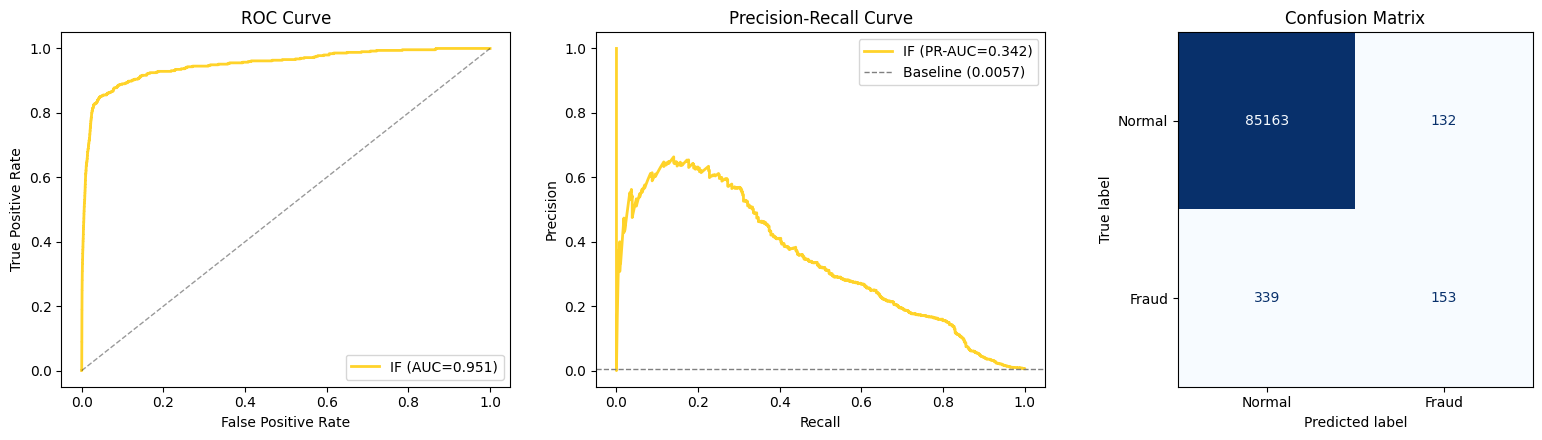

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(y_test, test_scores)
axes[0].plot(fpr, tpr, color="#ffd32a", lw=2, label=f"IF (AUC={roc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

prec, rcl, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(rcl, prec, color="#ffd32a", lw=2, label=f"IF (PR-AUC={pra:.3f})")
axes[1].axhline(y_test.mean(), color="grey", ls="--", lw=1, label=f"Baseline ({y_test.mean():.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                        display_labels=["Normal", "Fraud"]).plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Confusion Matrix")

plt.tight_layout(); plt.show()

## Conclusion

On the synthetic project, Isolation Forest scored ROC-AUC = 0.831 / PR-AUC = 0.055 against
self-generated "top 0.5% by amount" labels. On this real, independently labeled dataset, the exact
same technique — unsupervised, trained only on normal transactions, same model hyperparameters —
scores **ROC-AUC = 0.951 / PR-AUC = 0.342 / Recall = 0.311**, correctly flagging 31% of all real
frauds with 54% precision (barely 1 in 2 flags is a false alarm), on a class that's only 0.17% of
the data.

**The real numbers came out *better* than the synthetic evaluation, not worse.** That's a genuinely
useful result: it means the earlier synthetic evaluation wasn't overstating the approach — if
anything, the "top 0.5% by amount" synthetic labels were a harder, noisier target (amount alone is
a much weaker signal than real fraud patterns) than actual fraud. This is the direct answer to
"does this actually work": on a real, independently labeled benchmark, unsupervised Isolation
Forest catches roughly a third of all fraud with better-than-coin-flip precision, using no labels
at training time at all.

**What this validates:** the modeling *approach* (unsupervised isolation on scaled numeric
features, training on normal-only data, percentile-based thresholding) transfers to a real fraud
problem without any changes beyond swapping in the real contamination rate. **What it doesn't
validate:** the specific *engineered features* from the synthetic project (MerchDev, VelocityFlag,
LocationRiskScore, hour-of-day) — this dataset's features are pre-anonymized PCA components with
no timestamp, so that part of the original feature-engineering work couldn't be reused or tested
here, and the split here is random rather than temporal.